# Loss Landscape and Training Dynamics

This notebook studies a narrower question than notebook `03`.

We now assume the PDE statement and the boundary conditions are already written down correctly. The remaining issue is optimization: why can PINN training still drift, stall, or satisfy one term of the objective much faster than another?

## Notebook Contract

- **Status:** core-executable
- **Research question:** How do loss-weight choices reshape gradient balance, local loss geometry, and solution quality for a simple PINN?
- **Canonical problem:** 1D Poisson equation with soft Dirichlet boundary constraints
- **Main comparison:** balanced objective vs physics-dominated objective from the same initialization

## Why This Notebook Exists

Notebook `02` introduced the first vanilla PINN. Notebook `03` showed that even the way we enforce constraints can change optimization behavior.

This notebook isolates a third issue: **loss geometry**. A PINN objective is usually a sum of several terms with different scales and different gradients. Even when each term is mathematically correct, the optimizer can still favor one part of the problem over another.

We will keep the experiment deliberately controlled:

- the same PDE,
- the same collocation grid,
- the same architecture,
- the same optimizer,
- the same initialization.

Only the boundary-condition weight changes. That lets us watch how a small change in the objective reshapes the training trajectory.

In [1]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE and Objective

We return to the same 1D Poisson problem from notebook `02`:

$$
- u''(x) = f(x), \qquad x \in (0, 1), \qquad u(0) = u(1) = 0,
$$

with

$$
f(x) = \pi^2 \sin(\pi x), \qquad u^*(x) = \sin(\pi x).
$$

The PINN objective is

$$
\mathcal{L}(\theta) = \mathcal{L}_{physics}(\theta) + \lambda_{bc}\,\mathcal{L}_{bc}(\theta),
$$

where

$$
\mathcal{L}_{physics} = \frac{1}{N_r}\sum_{i=1}^{N_r}\left|-u_\theta''(x_i^{(r)}) - f(x_i^{(r)})\right|^2,
\qquad
\mathcal{L}_{bc} = \frac{1}{2}\left(|u_\theta(0)|^2 + |u_\theta(1)|^2\right).
$$

This is the smallest setting where we can still see an important optimization trade-off: if $\lambda_{bc}$ is too small, the network may reduce the PDE residual quickly while leaving the boundary mismatch behind.

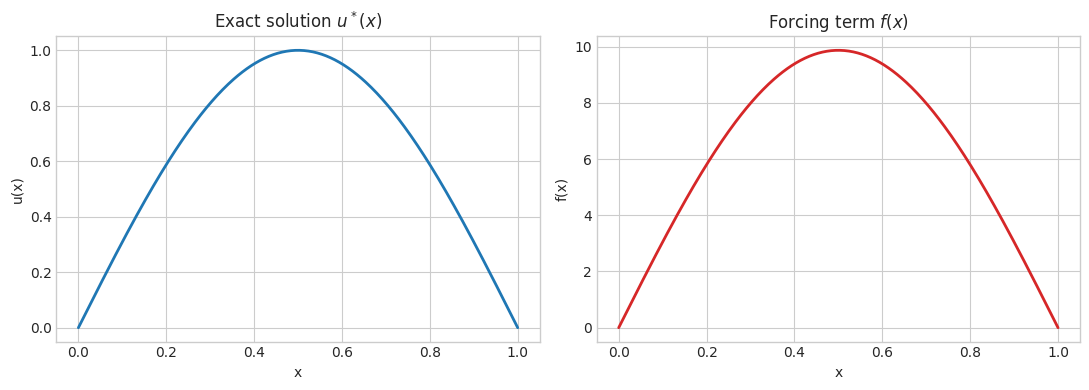

In [2]:
def exact_solution_np(x: np.ndarray) -> np.ndarray:
    return np.sin(np.pi * x)


def forcing_np(x: np.ndarray) -> np.ndarray:
    return (np.pi ** 2) * np.sin(np.pi * x)


def exact_solution_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(torch.pi * x)


def forcing_torch(x: torch.Tensor) -> torch.Tensor:
    return (torch.pi ** 2) * torch.sin(torch.pi * x)


x_plot = np.linspace(0.0, 1.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_plot, exact_solution_np(x_plot), color="tab:blue", linewidth=2)
axes[0].set_title("Exact solution $u^*(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")

axes[1].plot(x_plot, forcing_np(x_plot), color="tab:red", linewidth=2)
axes[1].set_title("Forcing term $f(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()

## Experimental Design

We compare two training regimes that differ only in the boundary-condition weight:

- **balanced:** $\lambda_{bc} = 50$, so the boundary term has a meaningful voice in the update direction,
- **physics-dominated:** $\lambda_{bc} = 1$, so the PDE residual dominates the optimization much more strongly.

For both runs we keep fixed:

- one hidden-layer family of the same width and depth,
- one deterministic interior grid,
- the same Adam learning rate,
- the same number of optimization steps,
- the same initialization.

We then track four signals:

1. the physics, boundary, and total losses,
2. the solution error and boundary violation,
3. the gradient norms contributed by each loss term,
4. a **local 2D loss slice** in parameter space.

That last plot is only a probe, not the full global loss landscape. But it is still useful for seeing whether the objective is locally broad, narrow, tilted, or sharply anisotropic around the points visited by training.

In [3]:
def gradient(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def second_derivative(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return gradient(gradient(y, x), x)


def make_interior_grid(num_points: int) -> torch.Tensor:
    x = torch.linspace(0.0, 1.0, num_points + 2, device=device).view(-1, 1)[1:-1]
    return x.clone().detach().requires_grad_(True)


def make_boundary_points() -> torch.Tensor:
    return torch.tensor([[0.0], [1.0]], device=device)


class VanillaPINN(nn.Module):
    def __init__(self, width: int = 24, depth: int = 2):
        super().__init__()
        layers: list[nn.Module] = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def pinn_losses(
    model: nn.Module,
    x_interior: torch.Tensor,
    x_boundary: torch.Tensor,
    bc_weight: float,
) -> dict[str, torch.Tensor]:
    u_interior = model(x_interior)
    residual = -second_derivative(u_interior, x_interior) - forcing_torch(x_interior)
    physics_loss = torch.mean(residual.square())
    boundary_values = model(x_boundary)
    boundary_loss = torch.mean(boundary_values.square())
    total_loss = physics_loss + bc_weight * boundary_loss
    return {
        "total": total_loss,
        "physics": physics_loss,
        "boundary": boundary_loss,
        "residual": residual,
        "boundary_values": boundary_values,
    }

In [4]:
def model_parameter_vector(model: nn.Module) -> torch.Tensor:
    return parameters_to_vector([parameter.detach().cpu().clone() for parameter in model.parameters()])


def set_model_parameter_vector(model: nn.Module, vector: torch.Tensor) -> None:
    vector_to_parameters(vector.to(device), model.parameters())


def loss_grad_vector(loss: torch.Tensor, model: nn.Module) -> torch.Tensor:
    params = [parameter for parameter in model.parameters() if parameter.requires_grad]
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )
    filled_grads = [
        torch.zeros_like(parameter) if grad is None else grad
        for parameter, grad in zip(params, grads)
    ]
    return parameters_to_vector([grad.detach().cpu() for grad in filled_grads])


def evaluate_model(model: nn.Module, x_boundary: torch.Tensor):
    x_eval = torch.linspace(0.0, 1.0, 401, device=device).view(-1, 1)
    x_eval = x_eval.clone().detach().requires_grad_(True)

    u_pred = model(x_eval)
    u_exact = exact_solution_torch(x_eval)
    residual = -second_derivative(u_pred, x_eval) - forcing_torch(x_eval)
    boundary_values = model(x_boundary)

    metrics = {
        "max_error": torch.max(torch.abs(u_pred - u_exact)).detach().item(),
        "l2_error": torch.sqrt(torch.mean((u_pred - u_exact).square())).detach().item(),
        "mean_abs_residual": torch.mean(torch.abs(residual)).detach().item(),
        "mean_abs_boundary_violation": torch.mean(torch.abs(boundary_values)).detach().item(),
    }
    fields = {
        "x": x_eval.detach().cpu().numpy().ravel(),
        "u_pred": u_pred.detach().cpu().numpy().ravel(),
        "u_exact": u_exact.detach().cpu().numpy().ravel(),
        "residual": residual.detach().cpu().numpy().ravel(),
    }
    return metrics, fields


def snapshot(
    model: nn.Module,
    step: int,
    bc_weight: float,
    x_interior: torch.Tensor,
    x_boundary: torch.Tensor,
) -> dict[str, float | int | torch.Tensor]:
    losses = pinn_losses(
        model=model,
        x_interior=x_interior,
        x_boundary=x_boundary,
        bc_weight=bc_weight,
    )
    physics_grad = loss_grad_vector(losses["physics"], model)
    boundary_grad = loss_grad_vector(losses["boundary"], model)
    total_grad = loss_grad_vector(losses["total"], model)

    denominator = physics_grad.norm() * boundary_grad.norm()
    if denominator.item() == 0.0:
        grad_cosine = 0.0
    else:
        grad_cosine = torch.dot(physics_grad, boundary_grad).item() / denominator.item()

    metrics, _ = evaluate_model(model=model, x_boundary=x_boundary)
    return {
        "step": step,
        "total": losses["total"].detach().item(),
        "physics": losses["physics"].detach().item(),
        "boundary": losses["boundary"].detach().item(),
        "max_error": metrics["max_error"],
        "l2_error": metrics["l2_error"],
        "mean_abs_residual": metrics["mean_abs_residual"],
        "mean_abs_boundary_violation": metrics["mean_abs_boundary_violation"],
        "physics_grad_norm": physics_grad.norm().item(),
        "weighted_boundary_grad_norm": bc_weight * boundary_grad.norm().item(),
        "total_grad_norm": total_grad.norm().item(),
        "grad_cosine": grad_cosine,
        "param_vector": model_parameter_vector(model),
    }

## Training Setup

The training budget stays modest so the notebook remains CPU-friendly:

- `63` interior collocation points,
- a width-`24`, depth-`2` MLP,
- Adam with learning rate `1e-3`,
- `1500` optimization steps,
- checkpoints every `150` steps.

The only thing we change between runs is the boundary-condition weight.

In [5]:
config = {
    "num_interior": 63,
    "width": 24,
    "depth": 2,
    "learning_rate": 1e-3,
    "steps": 1500,
    "log_every": 150,
    "balanced_bc_weight": 50.0,
    "physics_dominated_bc_weight": 1.0,
}

x_interior = make_interior_grid(config["num_interior"])
x_boundary = make_boundary_points()

base_model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
initial_state = deepcopy(base_model.state_dict())
initial_vector = model_parameter_vector(base_model)


def train_regime(label: str, bc_weight: float):
    model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
    model.load_state_dict(deepcopy(initial_state))
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        "step": [],
        "total": [],
        "physics": [],
        "boundary": [],
        "max_error": [],
        "l2_error": [],
        "mean_abs_residual": [],
        "mean_abs_boundary_violation": [],
        "physics_grad_norm": [],
        "weighted_boundary_grad_norm": [],
        "total_grad_norm": [],
        "grad_cosine": [],
        "param_vector": [],
    }

    def record(step: int) -> None:
        report = snapshot(
            model=model,
            step=step,
            bc_weight=bc_weight,
            x_interior=x_interior,
            x_boundary=x_boundary,
        )
        for key in history:
            history[key].append(report[key])
        print(
            f"[{label}] step={step:4d} | total={report['total']:.3e} | "
            f"physics={report['physics']:.3e} | boundary={report['boundary']:.3e} | "
            f"L2={report['l2_error']:.3e} | BC viol={report['mean_abs_boundary_violation']:.3e}"
        )

    record(step=0)
    for step in range(1, config["steps"] + 1):
        optimizer.zero_grad()
        losses = pinn_losses(
            model=model,
            x_interior=x_interior,
            x_boundary=x_boundary,
            bc_weight=bc_weight,
        )
        losses["total"].backward()
        optimizer.step()

        if step % config["log_every"] == 0 or step == config["steps"]:
            record(step=step)

    history["label"] = label
    history["bc_weight"] = bc_weight
    return model, history


balanced_model, balanced_history = train_regime(
    label="balanced",
    bc_weight=config["balanced_bc_weight"],
)
physics_model, physics_history = train_regime(
    label="physics-dominated",
    bc_weight=config["physics_dominated_bc_weight"],
)

[balanced] step=   0 | total=5.055e+01 | physics=4.951e+01 | boundary=2.086e-02 | L2=5.826e-01 | BC viol=1.416e-01
[balanced] step= 150 | total=1.456e+00 | physics=1.446e+00 | boundary=2.139e-04 | L2=8.704e-02 | BC viol=1.372e-02
[balanced] step= 300 | total=6.978e-03 | physics=6.976e-03 | boundary=2.091e-08 | L2=5.588e-04 | BC viol=1.251e-04
[balanced] step= 450 | total=3.546e-03 | physics=3.546e-03 | boundary=8.635e-09 | L2=3.316e-04 | BC viol=8.396e-05
[balanced] step= 600 | total=2.196e-03 | physics=2.196e-03 | boundary=3.588e-09 | L2=2.018e-04 | BC viol=4.935e-05
[balanced] step= 750 | total=1.761e-03 | physics=1.761e-03 | boundary=1.736e-09 | L2=1.451e-04 | BC viol=2.970e-05
[balanced] step= 900 | total=1.616e-03 | physics=1.616e-03 | boundary=1.071e-09 | L2=1.270e-04 | BC viol=2.632e-05
[balanced] step=1050 | total=1.538e-03 | physics=1.538e-03 | boundary=7.739e-10 | L2=1.202e-04 | BC viol=2.345e-05
[balanced] step=1200 | total=1.472e-03 | physics=1.472e-03 | boundary=6.297e-10 

## Final Evaluation

At the end of training we compare the learned solutions, the residuals, and the boundary violations on a dense evaluation grid.

In this fixed-seed experiment, the physics-dominated regime eventually reaches a smaller PDE residual, but it still finishes with noticeably larger boundary violation and worse solution error. That is the failure mode we care about: a PINN can look numerically strong on one objective term while still solving the full boundary-value problem less well.

In [6]:
balanced_metrics, balanced_fields = evaluate_model(balanced_model, x_boundary=x_boundary)
physics_metrics, physics_fields = evaluate_model(physics_model, x_boundary=x_boundary)

for label, bc_weight, metrics in [
    ("BALANCED", config["balanced_bc_weight"], balanced_metrics),
    ("PHYSICS-DOMINATED", config["physics_dominated_bc_weight"], physics_metrics),
]:
    print(label)
    print(f"  bc weight:               {bc_weight:.1f}")
    print(f"  max error:               {metrics['max_error']:.3e}")
    print(f"  L2 error:                {metrics['l2_error']:.3e}")
    print(f"  mean abs residual:       {metrics['mean_abs_residual']:.3e}")
    print(f"  mean abs BC violation:   {metrics['mean_abs_boundary_violation']:.3e}")

BALANCED
  bc weight:               50.0
  max error:               2.469e-04
  L2 error:                1.079e-04
  mean abs residual:       3.086e-02
  mean abs BC violation:   1.791e-05
PHYSICS-DOMINATED
  bc weight:               1.0
  max error:               1.085e-03
  L2 error:                5.821e-04
  mean abs residual:       2.124e-02
  mean abs BC violation:   9.272e-04


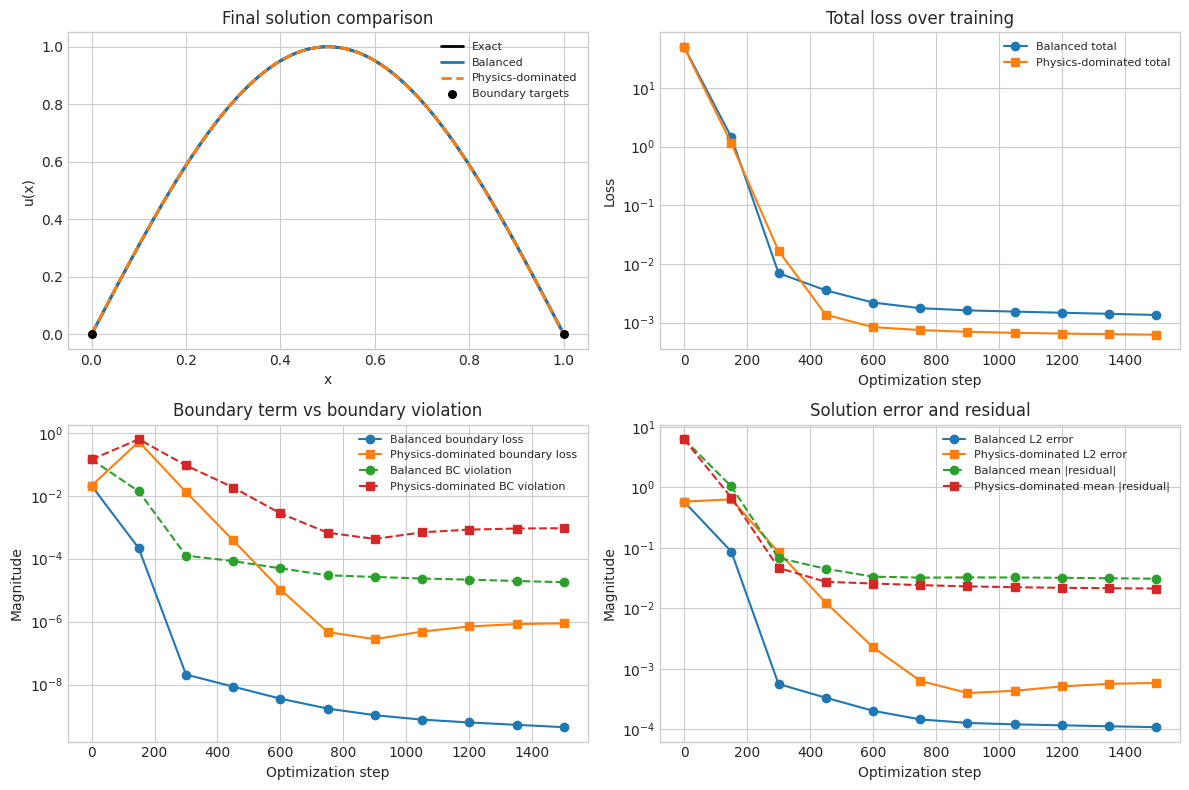

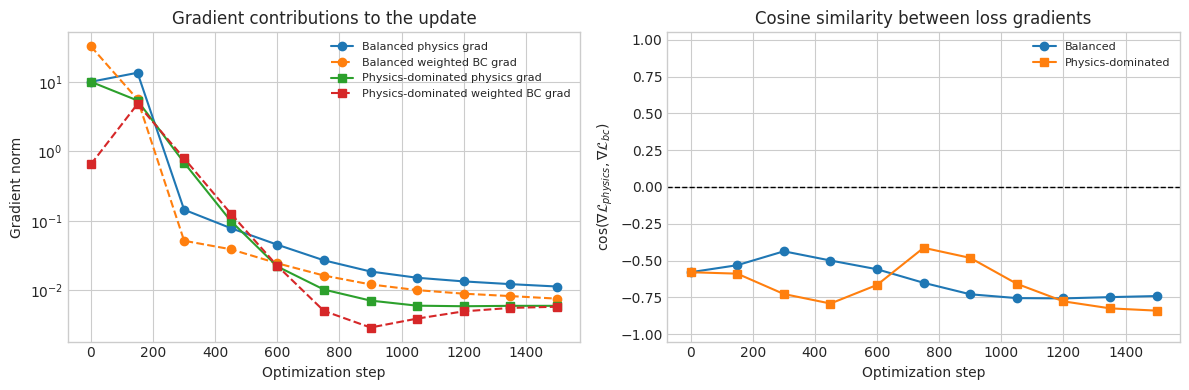

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(balanced_fields["x"], balanced_fields["u_exact"], label="Exact", linewidth=2, color="black")
axes[0, 0].plot(balanced_fields["x"], balanced_fields["u_pred"], label="Balanced", linewidth=2, color="tab:blue")
axes[0, 0].plot(physics_fields["x"], physics_fields["u_pred"], label="Physics-dominated", linewidth=2, linestyle="--", color="tab:orange")
axes[0, 0].scatter([0.0, 1.0], [0.0, 0.0], color="black", s=30, zorder=5, label="Boundary targets")
axes[0, 0].set_title("Final solution comparison")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("u(x)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(balanced_history["step"], balanced_history["total"], "o-", label="Balanced total")
axes[0, 1].plot(physics_history["step"], physics_history["total"], "s-", label="Physics-dominated total")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Total loss over training")
axes[0, 1].set_xlabel("Optimization step")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(balanced_history["step"], balanced_history["boundary"], "o-", label="Balanced boundary loss")
axes[1, 0].plot(physics_history["step"], physics_history["boundary"], "s-", label="Physics-dominated boundary loss")
axes[1, 0].plot(
    balanced_history["step"],
    balanced_history["mean_abs_boundary_violation"],
    "o--",
    label="Balanced BC violation",
)
axes[1, 0].plot(
    physics_history["step"],
    physics_history["mean_abs_boundary_violation"],
    "s--",
    label="Physics-dominated BC violation",
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Boundary term vs boundary violation")
axes[1, 0].set_xlabel("Optimization step")
axes[1, 0].set_ylabel("Magnitude")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(balanced_history["step"], balanced_history["l2_error"], "o-", label="Balanced L2 error")
axes[1, 1].plot(physics_history["step"], physics_history["l2_error"], "s-", label="Physics-dominated L2 error")
axes[1, 1].plot(balanced_history["step"], balanced_history["mean_abs_residual"], "o--", label="Balanced mean |residual|")
axes[1, 1].plot(physics_history["step"], physics_history["mean_abs_residual"], "s--", label="Physics-dominated mean |residual|")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Solution error and residual")
axes[1, 1].set_xlabel("Optimization step")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(balanced_history["step"], balanced_history["physics_grad_norm"], "o-", label="Balanced physics grad")
axes[0].plot(
    balanced_history["step"],
    balanced_history["weighted_boundary_grad_norm"],
    "o--",
    label="Balanced weighted BC grad",
)
axes[0].plot(physics_history["step"], physics_history["physics_grad_norm"], "s-", label="Physics-dominated physics grad")
axes[0].plot(
    physics_history["step"],
    physics_history["weighted_boundary_grad_norm"],
    "s--",
    label="Physics-dominated weighted BC grad",
)
axes[0].set_yscale("log")
axes[0].set_title("Gradient contributions to the update")
axes[0].set_xlabel("Optimization step")
axes[0].set_ylabel("Gradient norm")
axes[0].legend(fontsize=8)

axes[1].plot(balanced_history["step"], balanced_history["grad_cosine"], "o-", label="Balanced")
axes[1].plot(physics_history["step"], physics_history["grad_cosine"], "s-", label="Physics-dominated")
axes[1].axhline(0.0, color="black", linewidth=1, linestyle="--")
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title("Cosine similarity between loss gradients")
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel(r"$\cos(\nabla \mathcal{L}_{physics}, \nabla \mathcal{L}_{bc})$")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Local 2D Loss Slices

A full neural-network loss landscape lives in a very high-dimensional parameter space, so we cannot visualize it directly.

Instead, we inspect a **2D slice**. For each regime we build one axis along the training direction from the shared initialization to the final parameters, then add one random orthogonal direction. We evaluate the total loss on that plane:

- around the shared initialization,
- around the final parameters.

This is still only a local probe, but it is enough to show whether the objective is locally broad, tilted, or narrow in the directions actually visited during training.

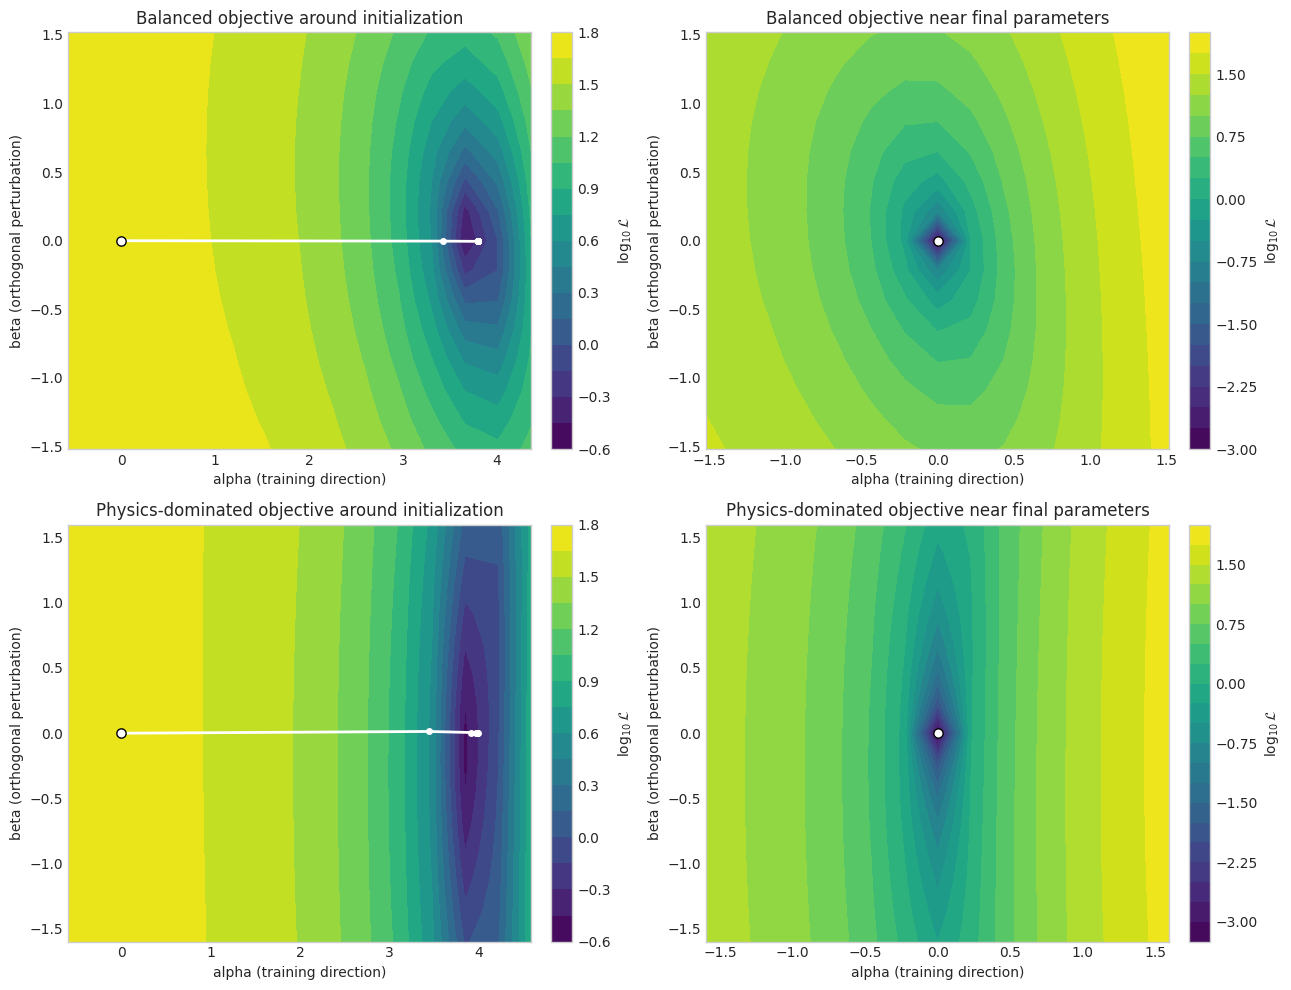

In [8]:
def normalize_direction(vector: torch.Tensor) -> torch.Tensor:
    norm = torch.linalg.vector_norm(vector)
    if norm.item() == 0.0:
        raise ValueError("Cannot normalize a zero vector.")
    return vector / norm


def make_orthogonal_direction(reference: torch.Tensor, seed: int) -> torch.Tensor:
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    candidate = torch.randn(reference.shape, generator=generator)
    candidate = candidate - torch.dot(candidate, reference) * reference
    return normalize_direction(candidate)


def trajectory_coordinates(
    vectors: list[torch.Tensor],
    center: torch.Tensor,
    direction_one: torch.Tensor,
    direction_two: torch.Tensor,
):
    alpha_values = []
    beta_values = []
    for vector in vectors:
        delta = vector - center
        alpha_values.append(torch.dot(delta, direction_one).item())
        beta_values.append(torch.dot(delta, direction_two).item())
    return np.array(alpha_values), np.array(beta_values)


def compute_loss_surface(
    center_vector: torch.Tensor,
    direction_one: torch.Tensor,
    direction_two: torch.Tensor,
    bc_weight: float,
    alpha_limits: tuple[float, float],
    beta_limits: tuple[float, float],
    grid_size: int = 15,
):
    probe_model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
    probe_model.load_state_dict(deepcopy(initial_state))

    alpha_values = np.linspace(alpha_limits[0], alpha_limits[1], grid_size)
    beta_values = np.linspace(beta_limits[0], beta_limits[1], grid_size)
    surface = np.zeros((grid_size, grid_size))

    for row, beta in enumerate(beta_values):
        for col, alpha in enumerate(alpha_values):
            vector = center_vector + alpha * direction_one + beta * direction_two
            set_model_parameter_vector(probe_model, vector)
            surface[row, col] = pinn_losses(
                model=probe_model,
                x_interior=x_interior,
                x_boundary=x_boundary,
                bc_weight=bc_weight,
            )["total"].detach().item()
    return alpha_values, beta_values, surface


balanced_final_vector = model_parameter_vector(balanced_model)
physics_final_vector = model_parameter_vector(physics_model)

balanced_direction = normalize_direction(balanced_final_vector - initial_vector)
physics_direction = normalize_direction(physics_final_vector - initial_vector)
balanced_orthogonal = make_orthogonal_direction(balanced_direction, seed=17)
physics_orthogonal = make_orthogonal_direction(physics_direction, seed=29)

balanced_distance = torch.linalg.vector_norm(balanced_final_vector - initial_vector).item()
physics_distance = torch.linalg.vector_norm(physics_final_vector - initial_vector).item()

balanced_init_alpha, balanced_init_beta, balanced_init_surface = compute_loss_surface(
    center_vector=initial_vector,
    direction_one=balanced_direction,
    direction_two=balanced_orthogonal,
    bc_weight=config["balanced_bc_weight"],
    alpha_limits=(-0.15 * balanced_distance, 1.15 * balanced_distance),
    beta_limits=(-0.40 * balanced_distance, 0.40 * balanced_distance),
)
balanced_final_alpha, balanced_final_beta, balanced_final_surface = compute_loss_surface(
    center_vector=balanced_final_vector,
    direction_one=balanced_direction,
    direction_two=balanced_orthogonal,
    bc_weight=config["balanced_bc_weight"],
    alpha_limits=(-0.40 * balanced_distance, 0.40 * balanced_distance),
    beta_limits=(-0.40 * balanced_distance, 0.40 * balanced_distance),
)
physics_init_alpha, physics_init_beta, physics_init_surface = compute_loss_surface(
    center_vector=initial_vector,
    direction_one=physics_direction,
    direction_two=physics_orthogonal,
    bc_weight=config["physics_dominated_bc_weight"],
    alpha_limits=(-0.15 * physics_distance, 1.15 * physics_distance),
    beta_limits=(-0.40 * physics_distance, 0.40 * physics_distance),
)
physics_final_alpha, physics_final_beta, physics_final_surface = compute_loss_surface(
    center_vector=physics_final_vector,
    direction_one=physics_direction,
    direction_two=physics_orthogonal,
    bc_weight=config["physics_dominated_bc_weight"],
    alpha_limits=(-0.40 * physics_distance, 0.40 * physics_distance),
    beta_limits=(-0.40 * physics_distance, 0.40 * physics_distance),
)

balanced_path_alpha, balanced_path_beta = trajectory_coordinates(
    vectors=balanced_history["param_vector"],
    center=initial_vector,
    direction_one=balanced_direction,
    direction_two=balanced_orthogonal,
)
physics_path_alpha, physics_path_beta = trajectory_coordinates(
    vectors=physics_history["param_vector"],
    center=initial_vector,
    direction_one=physics_direction,
    direction_two=physics_orthogonal,
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

surface_specs = [
    (
        axes[0, 0],
        balanced_init_alpha,
        balanced_init_beta,
        balanced_init_surface,
        "Balanced objective around initialization",
        (balanced_path_alpha, balanced_path_beta),
    ),
    (
        axes[0, 1],
        balanced_final_alpha,
        balanced_final_beta,
        balanced_final_surface,
        "Balanced objective near final parameters",
        None,
    ),
    (
        axes[1, 0],
        physics_init_alpha,
        physics_init_beta,
        physics_init_surface,
        "Physics-dominated objective around initialization",
        (physics_path_alpha, physics_path_beta),
    ),
    (
        axes[1, 1],
        physics_final_alpha,
        physics_final_beta,
        physics_final_surface,
        "Physics-dominated objective near final parameters",
        None,
    ),
]

for axis, alpha_values, beta_values, surface, title, path in surface_specs:
    contour = axis.contourf(
        alpha_values,
        beta_values,
        np.log10(surface + 1e-12),
        levels=20,
        cmap="viridis",
    )
    axis.scatter([0.0], [0.0], color="white", edgecolors="black", s=45, zorder=4)
    if path is not None:
        axis.plot(path[0], path[1], color="white", linewidth=2, marker="o", markersize=4)
    axis.set_title(title)
    axis.set_xlabel("alpha (training direction)")
    axis.set_ylabel("beta (orthogonal perturbation)")
    plt.colorbar(contour, ax=axis, fraction=0.046, pad=0.04, label=r"$\log_{10} \mathcal{L}$")

plt.tight_layout()
plt.show()

## Interpretation

This notebook makes one core point visible: **a correct PINN objective is not automatically an easy optimization problem**.

Here the balanced regime ends with lower solution error and much smaller boundary violation, even though the physics-dominated regime drives the mean residual slightly lower. That contrast matters. If we only watched the PDE residual, we might conclude that the physics-dominated run is better, but the actual boundary-value solution is worse.

The local loss slices reinforce the same lesson. Even on this tiny example, the objective is anisotropic and regime-dependent. Changing a single loss weight does not just rescale the numbers in the log; it changes the geometry that Adam is navigating.

## Key Takeaways

- PINN training dynamics depend on the **relative scale** of the loss terms, not just on whether each term is written down correctly.
- Tracking only the total loss or only the PDE residual can hide a real failure mode: one objective term can improve quickly while another remains poorly enforced.
- Gradient norms and gradient alignment are useful diagnostics when a PINN appears to be training but still gives poor solutions.
- A 2D loss slice is only a local probe, but it is often enough to reveal whether the optimization geometry is broad, sharp, or tilted in the directions that matter.

## Next Step

Notebook `05` will keep the optimization theme but move from **how the objective is weighted** to **where the objective is sampled**. Once we know that residual structure matters, the next question is whether we should keep collocation points fixed or adapt them toward the hard parts of the domain.